<a href="https://colab.research.google.com/github/chwankai/Waste-Classification-System-using-Computer-Vision/blob/main/TCV6313_1G_Group05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TCV6313 - COMPUTER VISION GROUP PROJECT
## GROUP 05
242UT2449P SEE CHWAN KAI

242UT2449Z KHO WEI CONG

242UT24490 TEO JING AN

1211203133 Kerk Yi

In [ ]:
# import libraries
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from keras.utils import to_categorical
from keras.src.optimizers import optimizer

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Seperate Dataset into Train, validation and test sets

In [ ]:
# Define the split ratio wiht train 70%, validation 15%, test 15%
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

img_size = 224
batch = 32
epoch = 20

source_dir = '/content/drive/MyDrive/Dataset'
dataset_dir = 'Dataset_Split'
random.seed(42)

# Naming the subdirectories for train, validation, and test sets
splits = ['train', 'val', 'test']
label = ["Plastic", "Paper", "Organic"]

# Creating folders for train, validation, and test sets
for split in splits:
    for class_name in os.listdir(source_dir):
        os.makedirs(os.path.join(dataset_dir, split, class_name), exist_ok=True)

# Splitting and copying files to respective directories
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    images = os.listdir(class_path)
    random.shuffle(images)

    # Set the split indices
    train_end = int(len(images) * train_ratio)
    val_end = train_end + int(len(images) * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Copy files to respective directories
    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(dataset_dir, 'train', class_name, img))
    for img in val_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(dataset_dir, 'val', class_name, img))
    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(dataset_dir, 'test', class_name, img))

    print(f"{class_name}: {len(train_images)} train, {len(val_images)} val, {len(test_images)} test")

Paper: 858 train, 184 val, 185 test
Plastic: 728 train, 156 val, 156 test
Organic: 809 train, 173 val, 174 test


#### Preprocessing the raw data

In [ ]:
# CLAHE
def apply_clahe(img):
    # Convert the image to LAB color space to separate brightness from color information
    img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    # Split the LAB image into its channels
    l, a, b = cv2.split(img)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    img = cv2.merge((l, a, b))
    img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
    # return image in RGB color space
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

# Guassion Blur
def apply_gaussian_blur(img):
    return cv2.GaussianBlur(img, (5, 5), 0)

# Sharpen
def apply_sharpen(img):
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])
    return cv2.filter2D(img, -1, kernel)

# Combine all preprocessing steps
def preprocess_image(img):
    img = img.astype(np.uint8)

    img = apply_clahe(img)
    img = apply_gaussian_blur(img)
    img = apply_sharpen(img)

    return img

#### Visualization compare raw images with image after prepocessing

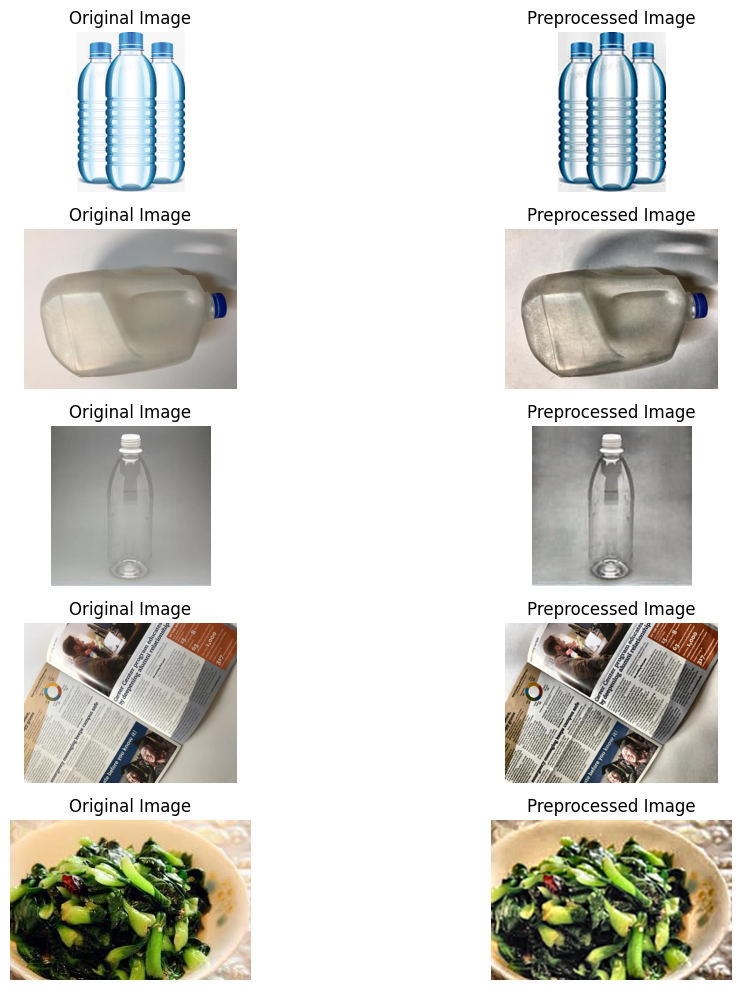

In [ ]:
all_images = []
trian_dir = "Dataset_Split/train"

for class_name in os.listdir(trian_dir):
    folder = os.path.join(trian_dir, class_name)
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        all_images.append(img_path)

# Randomly select 5 images to visualize preprocessing steps
random.shuffle(all_images)
sample_images = random.sample(all_images, 5)

plt.figure(figsize=(12, 10))

for i, path in enumerate(sample_images):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    preprocessed_img = preprocess_image(img)

    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(preprocessed_img, cmap='gray')
    plt.title('Preprocessed Image')
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Load Raw Datasets

In [ ]:
base_path = "Dataset_Split"

train_path = os.path.join(base_path, "train")
val_path   = os.path.join(base_path, "val")
test_path  = os.path.join(base_path, "test")

class_names = sorted(os.listdir(train_path))
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['Organic', 'Paper', 'Plastic']


In [ ]:
def load_images(folder_path, class_names):
    images = []
    labels = []

    for idx, class_name in enumerate(class_names):
        class_folder = os.path.join(folder_path, class_name)

        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))

            images.append(img)
            labels.append(idx)

    return np.array(images), np.array(labels)

In [ ]:
x_train, y_train = load_images(train_path, class_names)
x_val, y_val     = load_images(val_path, class_names)
x_test, y_test   = load_images(test_path, class_names)

print("Train:", x_train.shape)
print("Val:", x_val.shape)
print("Test:", x_test.shape)

Train: (2395, 224, 224, 3)
Val: (513, 224, 224, 3)
Test: (515, 224, 224, 3)


# Model 1: HOG + SVM

#### Without Apply Preprocess

In [ ]:
def extract_hog_features(images):
    features = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hog_feature = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        features.append(hog_feature)
    return np.array(features)

In [ ]:
X_train_hog = extract_hog_features(x_train)
X_test_hog  = extract_hog_features(x_test)

# Feature scaling
scaler = StandardScaler()
X_train_hog = scaler.fit_transform(X_train_hog)
X_test_hog  = scaler.transform(X_test_hog)

svm = SVC(kernel='linear')
svm.fit(X_train_hog, y_train)

# Predictions
y_train_pred = svm.predict(X_train_hog)
y_test_pred = svm.predict(X_test_hog)

hog_precision = precision_score(y_test, y_test_pred, average='weighted')
hog_recall = recall_score(y_test, y_test_pred, average='weighted')
hog_f1 = f1_score(y_test, y_test_pred, average='weighted')

hog_train_acc = accuracy_score(y_train, svm.predict(X_train_hog))
hog_test_acc = accuracy_score(y_test, svm.predict(X_test_hog))

# Display
print(f"HOG + SVM Train Accuracy : {hog_train_acc:.4f}")
print(f"HOG + SVM Test Accuracy  : {hog_test_acc:.4f}")
print(f"HOG + SVM Precision      : {hog_precision:.4f}")
print(f"HOG + SVM Recall         : {hog_recall:.4f}")
print(f"HOG + SVM F1-Score       : {hog_f1:.4f}")

HOG + SVM Train Accuracy : 1.0000
HOG + SVM Test Accuracy  : 0.6990
HOG + SVM Precision      : 0.6984
HOG + SVM Recall         : 0.6990
HOG + SVM F1-Score       : 0.6981


#### With Apply Preprocessing

In [ ]:
def extract_hog_features_pre(images):
    features = []
    for img in images:
        pre = preprocess_image(img) # preprocessing
        gray = cv2.cvtColor(pre, cv2.COLOR_RGB2GRAY)
        hog_feature = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        features.append(hog_feature)
    return np.array(features)

In [ ]:
# Extract HOG features (preprocessed)
X_train_hog_pre = extract_hog_features_pre(x_train)
X_test_hog_pre  = extract_hog_features_pre(x_test)

# Feature scaling
scaler = StandardScaler()
X_train_hog_pre = scaler.fit_transform(X_train_hog_pre)
X_test_hog_pre  = scaler.transform(X_test_hog_pre)

# Train SVM
svm_pre = SVC(kernel='linear')
svm_pre.fit(X_train_hog_pre, y_train)

# Predictions
y_train_pred_pre = svm_pre.predict(X_train_hog_pre)
y_test_pred_pre  = svm_pre.predict(X_test_hog_pre)

# Metrics
hog_train_acc_pre = accuracy_score(y_train, y_train_pred_pre)
hog_test_acc_pre  = accuracy_score(y_test, y_test_pred_pre)

hog_precision_pre = precision_score(y_test, y_test_pred_pre, average='weighted')
hog_recall_pre    = recall_score(y_test, y_test_pred_pre, average='weighted')
hog_f1_pre        = f1_score(y_test, y_test_pred_pre, average='weighted')

# Display
print(f"HOG + SVM Train Accuracy : {hog_train_acc_pre:.4f}")
print(f"HOG + SVM Test Accuracy  : {hog_test_acc_pre:.4f}")
print(f"HOG + SVM Precision      : {hog_precision_pre:.4f}")
print(f"HOG + SVM Recall         : {hog_recall_pre:.4f}")
print(f"HOG + SVM F1-Score       : {hog_f1_pre:.4f}")

HOG + SVM Train Accuracy : 1.0000
HOG + SVM Test Accuracy  : 0.6641
HOG + SVM Precision      : 0.6639
HOG + SVM Recall         : 0.6641
HOG + SVM F1-Score       : 0.6638


Separate Preprocessing with Raw for ResNet and VGG

In [ ]:
def preprocess_image(image, label, mode="raw"):
    image = tf.cast(image, tf.float32)

    if mode == "raw":
        image = image / 255.0  # normalization

    elif mode == "imagenet":
        image = preprocess_input(image)  # ImageNet preprocessing

    return image, label

In [ ]:
train_raw = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
    .map(lambda x, y: preprocess_image(x, y, "raw")) \
    .batch(batch)

val_raw = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
    .map(lambda x, y: preprocess_image(x, y, "raw")) \
    .batch(batch)

test_raw = tf.data.Dataset.from_tensor_slices((x_test, y_test)) \
    .map(lambda x, y: preprocess_image(x, y, "raw")) \
    .batch(batch)

In [ ]:
train_pre = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
    .map(lambda x, y: preprocess_image(x, y, "imagenet")) \
    .batch(batch)

val_pre = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
    .map(lambda x, y: preprocess_image(x, y, "imagenet")) \
    .batch(batch)

test_pre = tf.data.Dataset.from_tensor_slices((x_test, y_test)) \
    .map(lambda x, y: preprocess_image(x, y, "imagenet")) \
    .batch(batch)

# Model 2: ResNet50

In [ ]:
def build_resnet(num_classes):
    base = ResNet50(weights="imagenet", include_top=False,
                    input_shape=(224, 224, 3))
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [ ]:
results = []

def eval_model(model, train_ds, val_ds, test_ds, name, preprocess, y_true):
    train_acc = model.evaluate(train_ds, verbose=0)[1]
    val_acc = model.evaluate(val_ds, verbose=0)[1]
    test_acc = model.evaluate(test_ds, verbose=0)[1]

    y_pred_prob = model.predict(test_ds)
    y_pred = np.argmax(y_pred_prob, axis=1)

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    results.append([name, preprocess, train_acc, val_acc, test_acc, precision, recall, f1])

#### Without Preprocessing

In [ ]:
resnet_raw = build_resnet(num_classes)
resnet_raw.fit(train_raw, validation_data=val_raw, epochs=epoch)
eval_model(resnet_raw, train_raw, val_raw, test_raw,
           "ResNet50", "No Preprocessing", y_test)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 294ms/step - accuracy: 0.8231 - loss: 1.6448 - val_accuracy: 0.3372 - val_loss: 1.1430
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.2411 - loss: 1.0926 - val_accuracy: 0.3587 - val_loss: 1.0929
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.6050 - loss: 1.1667 - val_accuracy: 0.3587 - val_loss: 1.1094
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.4198 - loss: 1.2185 - val_accuracy: 0.3587 - val_loss: 1.0877
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.5030 - loss: 1.1529 - val_accuracy: 0.3119 - val_loss: 1.0994
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.2416 - loss: 1.1228 - val_accuracy: 0.3138 - val_loss: 1.0994
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.0613 - loss: 1.1213 - val_accuracy: 0.3197 - val_loss: 1.0986
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### With Preprocessing

In [ ]:
resnet_pre = build_resnet(num_classes)
resnet_pre.fit(train_pre, validation_data=val_pre, epochs=epoch)
eval_model(resnet_pre, train_pre, val_pre, test_pre,
           "ResNet50", "With Preprocessing", y_test)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 231ms/step - accuracy: 0.7876 - loss: 3.8422 - val_accuracy: 0.3041 - val_loss: 1.3793
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.1611 - loss: 1.3131 - val_accuracy: 0.5478 - val_loss: 0.9543
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.2879 - loss: 1.0623 - val_accuracy: 0.6491 - val_loss: 0.9284
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.8744 - loss: 0.9590 - val_accuracy: 0.3080 - val_loss: 1.7919
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.2958 - loss: 1.3351 - val_accuracy: 0.7154 - val_loss: 0.7747
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.9180 - loss: 0.8653 - val_accuracy: 0.7856 - val_loss: 0.7122
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9409 - loss: 0.8256 - val_accuracy: 0.8674 - val_loss: 0.5464
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.7419 - loss: 0.9629 - val_accuracy: 

# Model 3: VGG16

In [ ]:
def build_vgg16(num_classes):
    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### Without Preprocessing

In [ ]:
vgg_raw = build_vgg16(num_classes)
vgg_raw.fit(train_raw, validation_data=val_raw, epochs=epoch)
eval_model(vgg_raw, train_raw, val_raw, test_raw,
           "VGG16", "No Preprocessing", y_test)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 416ms/step - accuracy: 0.7708 - loss: 1.1789 - val_accuracy: 0.3041 - val_loss: 2.9135
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 203ms/step - accuracy: 0.1684 - loss: 2.8782 - val_accuracy: 0.3041 - val_loss: 1.2521
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 201ms/step - accuracy: 0.3057 - loss: 1.3467 - val_accuracy: 0.3255 - val_loss: 1.2798
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 203ms/step - accuracy: 0.2744 - loss: 1.3284 - val_accuracy: 0.4756 - val_loss: 0.9420
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.4751 - loss: 0.9986 - val_accuracy: 0.4620 - val_loss: 0.9471
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - accuracy: 0.5043 - loss: 0.9870 - val_accuracy: 0.6023 - val_loss: 0.8033
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.6181 - loss: 0.8281 - val_accuracy: 0.5244 - val_loss: 0.9009
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 204m

#### With Preprocessing

In [ ]:
vgg_pre = build_vgg16(num_classes)
vgg_pre.fit(train_pre, validation_data=val_pre, epochs=epoch)
eval_model(vgg_pre, train_pre, val_pre, test_pre,
           "VGG16", "With Preprocessing", y_test)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - accuracy: 0.8205 - loss: 4.7670 - val_accuracy: 0.3041 - val_loss: 53.1101
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - accuracy: 0.5004 - loss: 20.6572 - val_accuracy: 0.6062 - val_loss: 2.6728
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 209ms/step - accuracy: 0.8017 - loss: 0.9426 - val_accuracy: 0.7661 - val_loss: 0.9052
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - accuracy: 0.8927 - loss: 0.3413 - val_accuracy: 0.7914 - val_loss: 0.7830
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.9181 - loss: 0.2712 - val_accuracy: 0.8889 - val_loss: 0.3086
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.9308 - loss: 0.1789 - val_accuracy: 0.8967 - val_loss: 0.2497
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - accuracy: 0.9521 - loss: 0.1214 - val_accuracy: 0.9123 - val_loss: 0.2068
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 207ms/step - accuracy: 0.9621 - loss: 0.1016 - val_ac

# Result DataFrame

In [ ]:
results.append([
    "HOG + SVM",
    "No Preprocessing",
    hog_train_acc,
    None,
    hog_test_acc,
    hog_precision,
    hog_recall,
    hog_f1
])

results.append([
    "HOG + SVM",
    "With Preprocessing",
    hog_train_acc_pre,
    None,
    hog_test_acc_pre,
    hog_precision_pre,
    hog_recall_pre,
    hog_f1_pre
])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Preprocessing", "Train Accuracy",
             "Val Accuracy", "Test Accuracy", "Precision", "Recall", "F1-Score"]
)

results_df

,Model,Preprocessing,Train Accuracy,Val Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,ResNet50,No Preprocessing,0.358246,0.358674,0.359223,0.129041,0.359223,0.189875
1,ResNet50,With Preprocessing,0.965762,0.935673,0.939806,0.941096,0.939806,0.940123
2,VGG16,No Preprocessing,0.797912,0.799220,0.809709,0.846318,0.809709,0.811474
3,VGG16,With Preprocessing,0.998330,0.947368,0.963107,0.963214,0.963107,0.963138
4,HOG + SVM,No Preprocessing,1.000000,NaN,0.699029,0.698367,0.699029,0.698127
5,HOG + SVM,With Preprocessing,1.000000,NaN,0.664078,0.663930,0.664078,0.663831
